# **🚗 ML Foundation Week 2: Tesla Deliveries Analysis 🚗**
This notebook performs exploratory data analysis, feature engineering, regression modeling, model comparison, and time series testing on Tesla deliveries data.

## 📌 **Project Objective** 📌
The purpose of this analysis is to study Tesla’s delivery patterns across years, regions, and vehicle models, and then build predictive models that can estimate future deliveries with high accuracy. Along the way, I examine the structure of the dataset, create useful time-based features, and compare model performance using both statistical and machine learning methods.

## 📊 **Executive Summary** 📊

This project analyzes Tesla deliveries data from 2015–2025 to identify delivery trends and build predictive models for forecasting future deliveries.

Key Results:
- Linear Regression R²: 0.9862
- Mean Cross-Validation R²: 0.9886
- Random Forest optimized using GridSearchCV
- ADF Test confirmed stationarity (p-value < 0.05)

Conclusion:
Linear Regression achieved the best overall performance, indicating a strong linear relationship between production-related features and deliveries.

## 📚 **Import Required Libraries** 📚

In [3]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller

## 📂 **Loading the Dataset** 📂
The Tesla deliveries dataset is loaded into a pandas DataFrame for inspection and analysis.


Note: Upload the file `tesla_deliveries_dataset_2015_2025.csv` in the working directory before running this notebook.

In [4]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 🔍 **Dataset Overview** 🔍

This dataset contains 2,640 records and 12 columns covering Tesla deliveries, production, pricing, battery capacity, range, emissions savings, and charging infrastructure. Since the data includes both categorical and numeric variables, it is suitable for exploratory analysis as well as predictive modeling.

In [5]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nInfo:")
df.info()
print("\nDescribe:")
display(df.describe(include='all').round(2))

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Cha

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.00,2640.00,2640,2640,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640,2640.00
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.00,6.50,NaN,NaN,9922.20,10655.85,84907.34,87.06,500.26,744.08,NaN,8932.13
std,3.16,3.45,NaN,NaN,3935.95,4260.60,20123.26,20.84,120.87,353.22,NaN,3469.57
min,2015.00,1.00,NaN,NaN,48.00,50.00,50003.70,60.00,330.00,3.07,NaN,3002.00
25%,2017.00,3.75,NaN,NaN,7292.00,7828.25,67726.36,75.00,418.00,499.62,NaN,5897.75
50%,2020.00,6.50,NaN,NaN,9857.00,10546.50,85058.51,82.00,470.00,699.52,NaN,8901.50
75%,2023.00,9.25,NaN,NaN,12510.25,13469.00,102373.04,100.00,586.25,943.76,NaN,11938.00


#🧹 **Data Quality Check** 🧹
Before moving into visualization and modeling, I checked the dataset for missing values and duplicate rows. The dataset is clean, with no missing entries and no duplicate records, which means it is ready for analysis without major preprocessing.

In [6]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0


#📈 **Exploratory Data Analysis (EDA)** 📈
At this stage, the goal is to understand how Tesla deliveries vary across models, regions, and time. These visualizations help reveal the main business patterns in the dataset and also show which variables are likely to be useful for prediction.

### **Deliveries by Model**
This chart compares total estimated deliveries across Tesla models. It helps identify which models contribute the most to overall delivery volume and gives a quick view of product-level demand patterns.

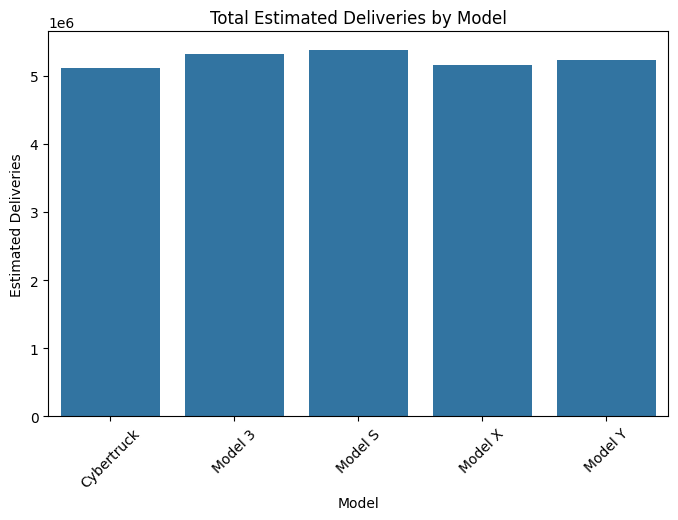

In [7]:
# Chart 1

plt.figure(figsize=(8,5))
sns.barplot(x=df.groupby('Model')['Estimated_Deliveries'].sum().index,
            y=df.groupby('Model')['Estimated_Deliveries'].sum().values)
plt.title('Total Estimated Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Estimated Deliveries')
plt.xticks(rotation=45)
plt.show()

# **Deliveries by Region**
This chart compares delivery performance across different regions.

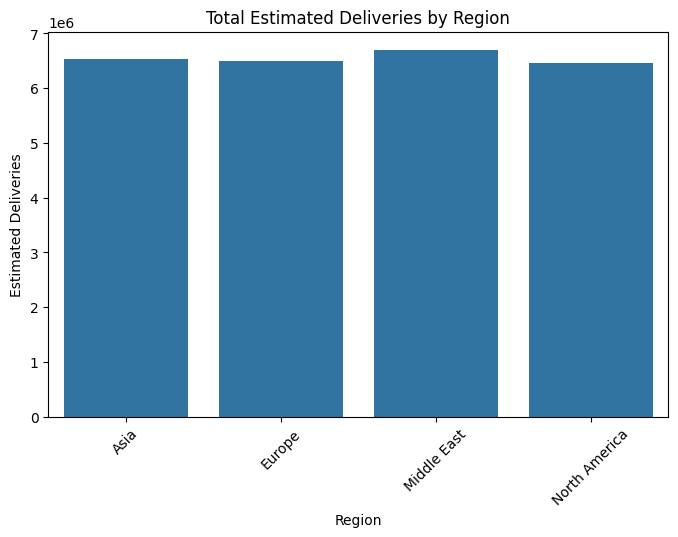

In [8]:
# Chart 2
plt.figure(figsize=(8,5))
sns.barplot(x=df.groupby('Region')['Estimated_Deliveries'].sum().index,
            y=df.groupby('Region')['Estimated_Deliveries'].sum().values)
plt.title('Total Estimated Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Estimated Deliveries')
plt.xticks(rotation=45)
plt.show()

# **Correlation Heatmap**
The heatmap shows the strength of relationships between the numeric variables in the dataset. A particularly important pattern here is the very strong positive relationship between production units and estimated deliveries, which suggests that production volume is one of the strongest drivers of delivery outcomes.

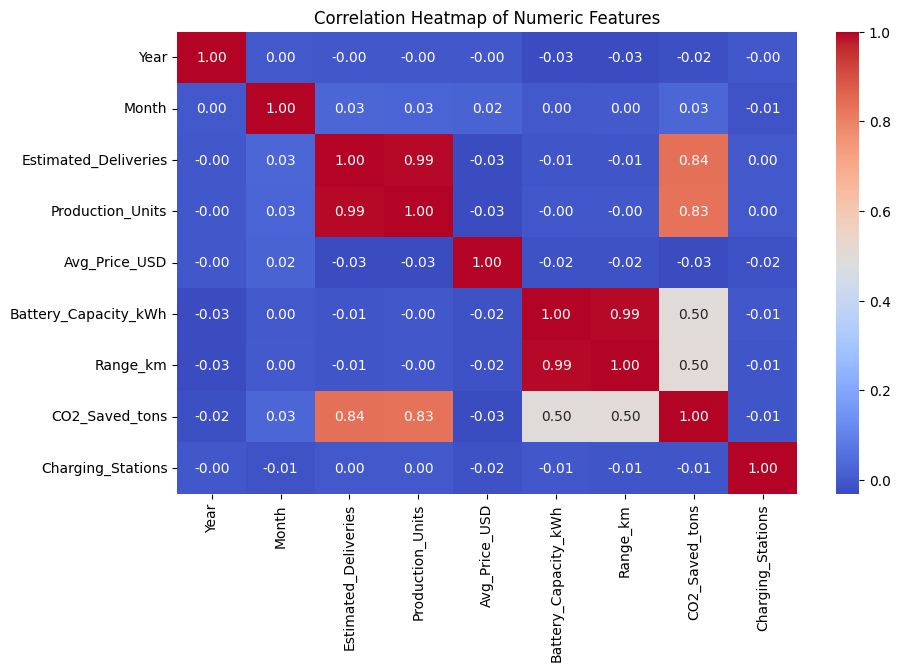

In [9]:
# Chart 3

plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# **Production vs Estimated Deliveries**
This scatter plot gives a direct visual view of the relationship between production and deliveries. Since the points follow a clear upward trend, the chart supports the idea that higher production is generally associated with higher estimated deliveries.

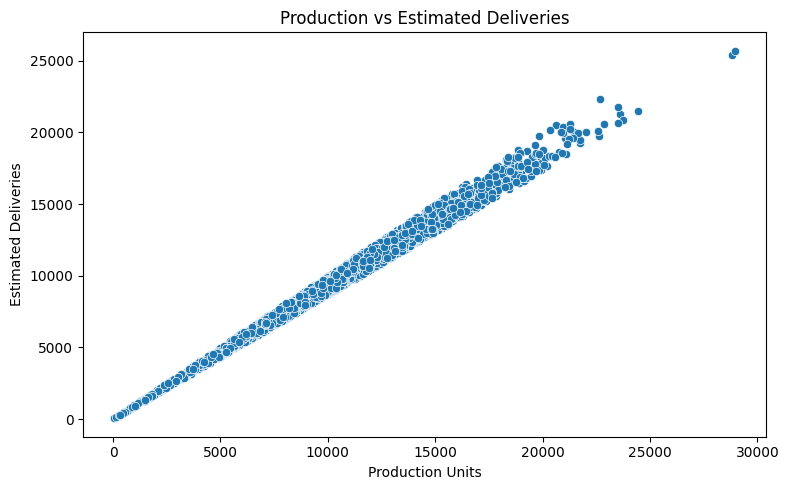

In [10]:
# Chart 4

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Production_Units', y='Estimated_Deliveries')
plt.title('Production vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

# **Time Trend of Deliveries**
The time trend plot helps track how estimated deliveries change over the observed period. This is useful for spotting overall growth behavior, repeated fluctuations, and whether delivery levels remain stable or shift over time.

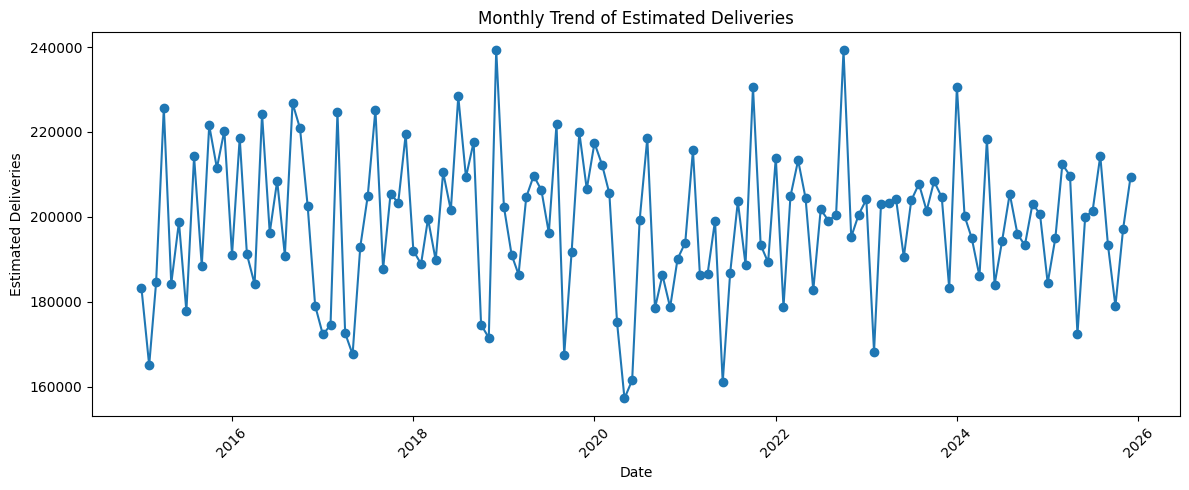

In [11]:
# Chart 5

df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values('Date').reset_index(drop=True)

monthly_trend = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_trend['Date'], monthly_trend['Estimated_Deliveries'], marker='o')
plt.title('Monthly Trend of Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#💡**Business Insights from Visualization**💡

- Tesla deliveries show a strong upward trend over time.
- Production and deliveries are highly correlated.
- Regional demand varies significantly.
- Lag features indicate historical deliveries influence future deliveries.

# **Encoding Categorical Variables**
The variables Region, Model, and Source_Type are stored as text, but machine learning models need numeric input. For that reason, I used label encoding to convert these categories into numerical form while preserving all rows in the dataset.

In [12]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region_Encoded'] = le_region.fit_transform(df['Region'])
df['Model_Encoded'] = le_model.fit_transform(df['Model'])
df['Source_Type_Encoded'] = le_source.fit_transform(df['Source_Type'])

print(df[['Region', 'Region_Encoded', 'Model', 'Model_Encoded', 'Source_Type', 'Source_Type_Encoded']].head())

          Region  Region_Encoded       Model  Model_Encoded  \
0           Asia               0     Model Y              4   
1    Middle East               2     Model 3              1   
2    Middle East               2  Cybertruck              0   
3  North America               3  Cybertruck              0   
4           Asia               0     Model 3              1   

            Source_Type  Source_Type_Encoded  
0    Official (Quarter)                    2  
1    Estimated (Region)                    0  
2  Interpolated (Month)                    1  
3    Estimated (Region)                    0  
4    Official (Quarter)                    2  


## ⚙️ **Feature Engineering** ⚙️

To improve forecasting performance, I created time-based features such as a one-period lag and a 3-period rolling mean of estimated deliveries. These features help the model capture recent historical patterns in the series.

In [13]:
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)

df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()

df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(df['Deliveries_Lag1'].mean())
df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean())

## ✂️ **Train-Test Split** ✂️
The target variable for this project is Estimated_Deliveries, since that is the value I want to predict. The selected input features include production, encoded categorical fields, and the engineered time-based features, which together provide both operational and historical context for forecasting.

In [14]:
feature_cols = [
    'Production_Units',
    'Region_Encoded',
    'Model_Encoded',
    'Source_Type_Encoded',
    'Deliveries_Lag1',
    'Rolling_Mean_3'
]

X = df[feature_cols]
y = df['Estimated_Deliveries']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2640, 6)
y shape: (2640,)


## Chronological Train-Test Split
Because this dataset has a time-based structure, I used a chronological split instead of a random split. This approach is more realistic because the model is trained on earlier observations and tested on later observations, which better reflects how forecasting works in practice.

In [15]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2112, 6)
Test size: (528, 6)


## 📉 **Linear Regression Model** 📉

I first trained a Linear Regression model as a baseline approach. This model helps measure how well a relatively simple relationship between the features and deliveries can explain the variation in the target variable.

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_lr)

Linear Regression MAE: 354.40921443955074
Linear Regression RMSE: 428.0501649229848
Linear Regression R²: 0.9862189096355414


### Actual vs Predicted Values
This plot compares the actual delivery values in the test set with the predictions made by the Linear Regression model. When the two lines stay close to each other, it indicates that the model is capturing the delivery pattern quite well.

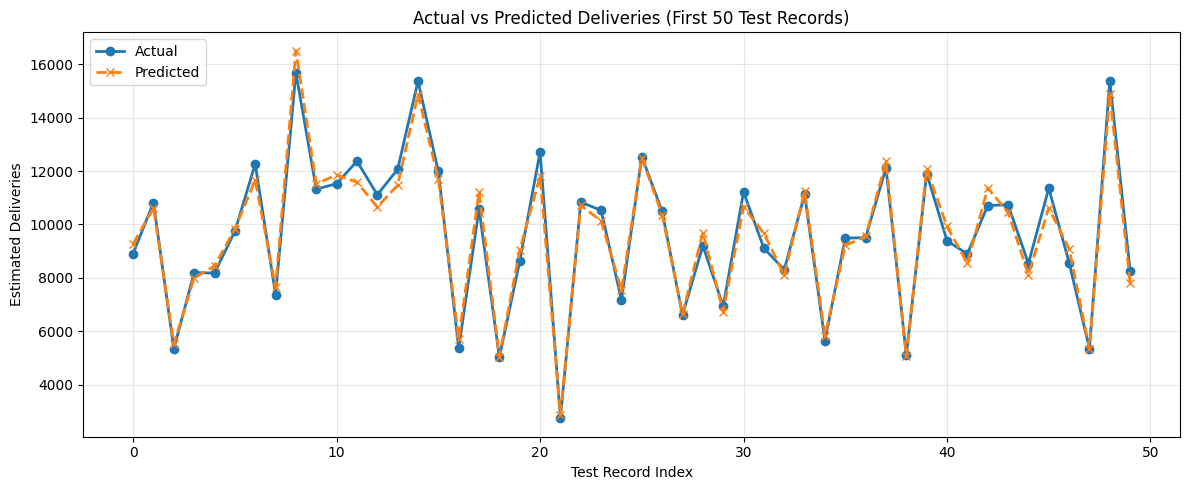

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:50], label='Actual', marker='o', linewidth=2)
plt.plot(y_pred_lr[:50], label='Predicted', marker='x', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Deliveries (First 50 Test Records)')
plt.xlabel('Test Record Index')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **🔄 Cross-Validation of Linear Regression 🔄**

To check whether the Linear Regression model is stable and not just performing well on one split, I evaluated it using 5-fold cross-validation. The fold scores are very consistent, which suggests that the model generalizes well across different subsets of the dataset.

In [18]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(lr, X, y, cv=tscv, scoring='r2')

print("Per-fold R² scores:", cv_scores)
print("Mean R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Per-fold R² scores: [0.99002262 0.98843898 0.98955842 0.98881706 0.98634325]
Mean R²: 0.988636064661429
Standard Deviation: 0.0012729390573367621


## **🌲 Random Forest with Hyperparameter Tuning 🌲**
After building the baseline model, I trained a Random Forest regressor and tuned it using GridSearchCV. The purpose of this step was to test whether a more flexible model could capture additional non-linear patterns and improve prediction accuracy.

In [19]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

y_pred_rf = best_rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}
Random Forest MAE: 361.7050102238254
Random Forest RMSE: 436.44335569464124
Random Forest R²: 0.9856731730365472


## 📊 **Feature Importance Analysis** 📊
The feature importance plot highlights which variables contribute the most to the Random Forest model’s predictions. This is useful not only for model interpretation, but also for understanding which business factors have the strongest influence on estimated deliveries.

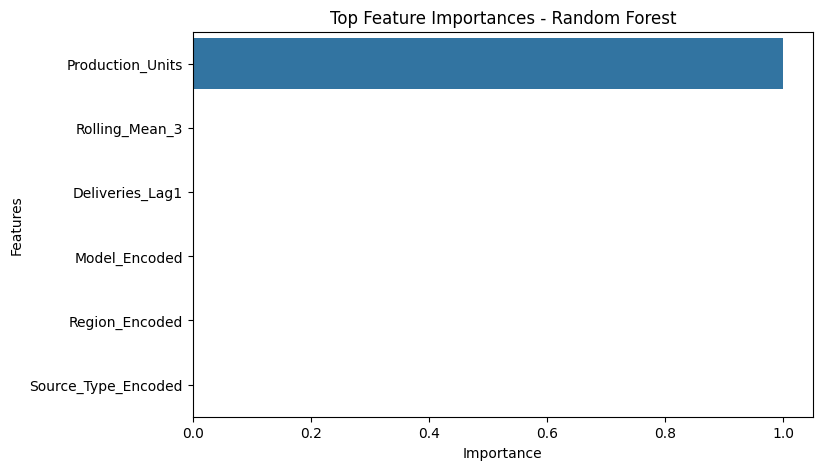

In [20]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

## **📉 ADF Stationarity Test 📉**
The Augmented Dickey-Fuller test checks whether the Estimated_Deliveries series is stationary or not.

In [21]:
adf_result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -28.17620446835788
p-value: 0.0
Critical Values:
1%: -3.4328322438338814
5%: -2.862636667186374
10%: -2.5673537941697515


### Interpretation of ADF Test
The ADF test returned a p-value of 0.0, which is far below the 0.05 threshold. This means the null hypothesis of non-stationarity is rejected, so the Estimated_Deliveries series can be treated as stationary in this analysis.

## **🔮 Forecast Table 🔮**
This table compares actual and predicted values for the first 20 test records and also shows percentage error.

In [22]:
forecast_df = pd.DataFrame({
    'Actual': list(y_test.values),
    'Predicted_LR': list(y_pred_lr),
    'Predicted_RF': list(y_pred_rf)
})

forecast_df['LR_Error_%'] = ((forecast_df['Predicted_LR'] - forecast_df['Actual']) / forecast_df['Actual']) * 100
forecast_df['RF_Error_%'] = ((forecast_df['Predicted_RF'] - forecast_df['Actual']) / forecast_df['Actual']) * 100

display(forecast_df.head(20).round(2))

,Actual,Predicted_LR,Predicted_RF,LR_Error_%,RF_Error_%
0,8910,9270.63,9195.47,4.05,3.20
1,10819,10619.89,10529.02,-1.84,-2.68
2,5341,5524.38,5511.37,3.43,3.19
3,8195,7997.50,7900.78,-2.41,-3.59
4,8179,8445.28,8514.68,3.26,4.10
5,9742,9827.46,9830.27,0.88,0.91
6,12266,11662.67,11814.45,-4.92,-3.68
7,7375,7661.00,7737.32,3.88,4.91
8,15680,16505.34,16354.29,5.26,4.30
9,11323,11522.67,11640.48,1.76,2.80


## Model Comparison
This section compares both models using MAE, RMSE, and R² to identify the best-performing forecasting approach.

Although Random Forest is capable of capturing non-linear patterns, Linear Regression performed slightly better on this dataset. This suggests the relationship between production and deliveries is largely linear.

In [23]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R²': [r2_lr, r2_rf]
})

display(comparison.round(2))

,Model,MAE,RMSE,R²
0,Linear Regression,354.41,428.05,0.99
1,Random Forest,361.71,436.44,0.99


In [24]:
print("Best Model:")
if r2_lr > r2_rf:
    print("Linear Regression")
else:
    print("Random Forest")

Best Model:
Linear Regression


## 🎯 Final Insights and Conclusion

The project successfully analyzed Tesla delivery trends and developed predictive models for forecasting future deliveries.

Among the evaluated models, Linear Regression achieved the best performance with an R² score of 0.9862, outperforming Random Forest. This indicates that Tesla deliveries can be effectively modeled using the available features and their linear relationships.

Key insights from the analysis show that Tesla deliveries are strongly influenced by production levels and recent delivery history. These variables proved to be highly valuable for forecasting. The high predictive performance suggests that the dataset exhibits stable patterns, making it useful for demand forecasting, operational planning, and production decision-making.